<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_model_robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w05_model_robustness_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Capstone Model Robustness & Validation Audit

## Search Impressions Decline — stronger validation before the final paper

This notebook keeps the same core Week-5 question and timeline, but strengthens the evidence before we make a capstone claim.

It adds six checks:

1. **Reproduce the original client-holdout setup** without changing the target.
2. Add a **momentum-only baseline** to test whether ML adds value beyond the obvious trend signal.
3. Make **random vs grouped CV apples-to-apples**: same model, same hyperparameters, same metric code.
4. Run **nested grouped validation** so each outer test fold contains unseen clients and hyperparameters are chosen only inside the corresponding outer training clients.
5. Run a **repeated client-holdout sensitivity check** to show how much Precision@100 changes when the seven-ish test clients change.
6. Report both pooled Precision@100 and **macro client Precision@100**, so one large client cannot silently dominate the story.

This notebook is not designed to chase a higher test score. A lower but more stable estimate is a stronger capstone result than one favorable point estimate.

**Prediction question:** using signals available through March 15, rank pages by risk that average daily impressions during March 16–31 will be more than 20% below the March 1–15 average.


In [1]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    ParameterGrid,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1


## 1. Connect to the approved FlyRank warehouse

The token is read from Colab Secrets when available. It is never hardcoded or printed.


In [3]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = HF_TOKEN.replace("'", "''")
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_MARCH = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    f")"
)

print("Connected successfully.")


Connected successfully.


## 2. Build the same modeling table

Timeline:

- **Early features:** March 1–7
- **Late features:** March 8–15
- **Outcome:** March 16–31

The outcome window is strictly after all model features.


In [4]:
query = f'''
SELECT
    client_hash_id AS client_id,
    content_hash_id AS content_id,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_early,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_early,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_early,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-07'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_early,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_late,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
             THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_late,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_late,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-08' AND DATE '2026-03-15'
                  AND COALESCE(gsc_impressions, 0) > 0
             THEN 1 ELSE 0 END) AS active_days_late,

    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
             THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future,
    SUM(CASE WHEN report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
                  AND COALESCE(gsc_data_available, FALSE)
             THEN 1 ELSE 0 END) AS gsc_days_future

FROM {FACT_MARCH}
WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
GROUP BY client_hash_id, content_hash_id
'''

df = con.execute(query).df()

print("Rows returned:", len(df))
print("Clients returned:", df["client_id"].nunique())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows returned: 331437
Clients returned: 55


In [5]:
# Complete GSC coverage across all three windows.
clean_df = df[
    (df["gsc_days_early"] == 7)
    & (df["gsc_days_late"] == 8)
    & (df["gsc_days_future"] == 16)
].copy()

clean_df["imp_first_half"] = clean_df["imp_early"] + clean_df["imp_late"]
clean_df["clicks_first_half"] = clean_df["clicks_early"] + clean_df["clicks_late"]
clean_df["sum_position_first_half"] = (
    clean_df["sum_position_early"] + clean_df["sum_position_late"]
)
clean_df["active_days_first_half"] = (
    clean_df["active_days_early"] + clean_df["active_days_late"]
)

# The percent-change target requires a non-zero reference level.
clean_df = clean_df[clean_df["imp_first_half"] > 0].copy()

clean_df["avg_daily_imp_first_half"] = clean_df["imp_first_half"] / 15.0
clean_df["avg_daily_imp_future"] = clean_df["imp_future"] / 16.0

clean_df["impression_change_pct"] = (
    (clean_df["avg_daily_imp_future"] - clean_df["avg_daily_imp_first_half"])
    / clean_df["avg_daily_imp_first_half"]
) * 100.0

clean_df["is_declining_proxy"] = (
    clean_df["impression_change_pct"] < -20
).astype(int)

print("Eligible pages before position filter:", len(clean_df))
print("Eligible clients:", clean_df["client_id"].nunique())
print("Decline rate:", f'{clean_df["is_declining_proxy"].mean():.1%}')


Eligible pages before position filter: 61796
Eligible clients: 34
Decline rate: 32.4%


## 3. Feature engineering — same information boundary as Week 5

The model sees both **level** and **momentum** before March 16. No future-window field is included.


In [6]:
# Level features.
clean_df["ctr_first_half"] = (
    clean_df["clicks_first_half"] / clean_df["imp_first_half"]
) * 100.0

clean_df["avg_position_first_half"] = np.where(
    clean_df["imp_first_half"] > 0,
    clean_df["sum_position_first_half"] / clean_df["imp_first_half"],
    np.nan,
)

clean_df["active_rate_first_half"] = clean_df["active_days_first_half"] / 15.0
clean_df["log_imp_first_half"] = np.log1p(clean_df["imp_first_half"])
clean_df["log_clicks_first_half"] = np.log1p(clean_df["clicks_first_half"])

# Early vs late daily levels.
clean_df["avg_daily_imp_early"] = clean_df["imp_early"] / 7.0
clean_df["avg_daily_imp_late"] = clean_df["imp_late"] / 8.0
clean_df["avg_daily_clicks_early"] = clean_df["clicks_early"] / 7.0
clean_df["avg_daily_clicks_late"] = clean_df["clicks_late"] / 8.0

clean_df["ctr_early"] = np.where(
    clean_df["imp_early"] > 0,
    (clean_df["clicks_early"] / clean_df["imp_early"]) * 100.0,
    0.0,
)
clean_df["ctr_late"] = np.where(
    clean_df["imp_late"] > 0,
    (clean_df["clicks_late"] / clean_df["imp_late"]) * 100.0,
    0.0,
)

clean_df["avg_position_early"] = np.where(
    clean_df["imp_early"] > 0,
    clean_df["sum_position_early"] / clean_df["imp_early"],
    np.nan,
)
clean_df["avg_position_late"] = np.where(
    clean_df["imp_late"] > 0,
    clean_df["sum_position_late"] / clean_df["imp_late"],
    np.nan,
)

# Momentum features.
early_imp_den = np.maximum(clean_df["avg_daily_imp_early"], 1.0)
clean_df["imp_momentum_pct"] = (
    (clean_df["avg_daily_imp_late"] - clean_df["avg_daily_imp_early"])
    / early_imp_den
) * 100.0

clean_df["imp_momentum_log"] = (
    np.log1p(clean_df["avg_daily_imp_late"])
    - np.log1p(clean_df["avg_daily_imp_early"])
)
clean_df["click_change_per_day"] = (
    clean_df["avg_daily_clicks_late"] - clean_df["avg_daily_clicks_early"]
)
clean_df["ctr_change_pp"] = clean_df["ctr_late"] - clean_df["ctr_early"]
clean_df["has_position_momentum"] = (
    clean_df["avg_position_early"].notna()
    & clean_df["avg_position_late"].notna()
).astype(int)
clean_df["position_change"] = (
    clean_df["avg_position_late"] - clean_df["avg_position_early"]
).fillna(0.0)
clean_df["active_rate_change"] = (
    clean_df["active_days_late"] / 8.0
    - clean_df["active_days_early"] / 7.0
)

model_df = clean_df[
    clean_df["avg_position_first_half"].notna()
    & (clean_df["avg_position_first_half"] > 0)
].copy().reset_index(drop=True)

feature_cols = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
    "imp_momentum_pct",
    "imp_momentum_log",
    "click_change_per_day",
    "ctr_change_pp",
    "position_change",
    "active_rate_change",
    "has_position_momentum",
]
target_col = "is_declining_proxy"

print("Modeling pages:", len(model_df))
print("Modeling clients:", model_df["client_id"].nunique())
print("Features:", len(feature_cols))
print("Missing feature values:", int(model_df[feature_cols].isna().sum().sum()))


Modeling pages: 61795
Modeling clients: 34
Features: 12
Missing feature values: 0


## 4. Coverage / selection audit

Complete-window filtering is reasonable for this experiment, but it narrows the population. We therefore report how many rows and clients remain instead of implying that the result covers every client in the warehouse.


In [7]:
coverage_summary = pd.DataFrame([
    {
        "stage": "March rows returned",
        "rows": len(df),
        "clients": df["client_id"].nunique(),
    },
    {
        "stage": "Final modeling population",
        "rows": len(model_df),
        "clients": model_df["client_id"].nunique(),
    },
])
coverage_summary["row_retention_vs_query"] = coverage_summary["rows"] / len(df)
coverage_summary["client_retention_vs_query"] = (
    coverage_summary["clients"] / df["client_id"].nunique()
)

display(
    coverage_summary.style.format({
        "row_retention_vs_query": "{:.1%}",
        "client_retention_vs_query": "{:.1%}",
    })
)

client_summary = (
    model_df.groupby("client_id")
    .agg(pages=(target_col, "size"), decline_rate=(target_col, "mean"))
)

print("Client-level page-count summary:")
display(client_summary["pages"].describe().to_frame().T)

print("Client-level decline-rate summary:")
decline_desc = client_summary["decline_rate"].describe().to_frame().T
display(
    decline_desc.style.format({
        c: "{:.1%}" for c in decline_desc.columns if c != "count"
    })
)


,stage,rows,clients,row_retention_vs_query,client_retention_vs_query
0,March rows returned,331437,55,100.0%,100.0%
1,Final modeling population,61795,34,18.6%,61.8%


Client-level page-count summary:


,count,mean,std,min,25%,50%,75%,max
pages,34.0,1817.5,3886.560646,1.0,9.0,295.0,1114.0,16648.0


Client-level decline-rate summary:


,count,mean,std,min,25%,50%,75%,max
decline_rate,34.000000,27.6%,19.1%,0.0%,12.8%,30.3%,37.8%,66.7%


## 5. Leakage and timeline audit

Important nuance: the target is a **future percentage change relative to the March 1–15 level**. The March 1–15 level is known at prediction time, so using it as a feature is not future leakage. Still, it is part of the target's reference definition, so we report that relationship rather than hiding it.


In [8]:
forbidden_exact = {
    target_col,
    "impression_change_pct",
    "imp_future",
    "avg_daily_imp_future",
    "client_id",
    "content_id",
}

future_features = [c for c in feature_cols if "future" in c.lower()]
forbidden_in_features = [c for c in feature_cols if c in forbidden_exact]

print("Feature window: 2026-03-01 through 2026-03-15")
print("Outcome window: 2026-03-16 through 2026-03-31")
print("Future-window features found:", future_features)
print("Forbidden/target/ID features found:", forbidden_in_features)

assert not future_features
assert not forbidden_in_features
assert model_df[feature_cols].isna().sum().sum() == 0

print("PASS: no direct future-window, target-derived, or ID feature is used.")
print(
    "NOTE: first-half impression level is a legal pre-outcome feature and also "
    "the reference level used to define future percent change."
)


Feature window: 2026-03-01 through 2026-03-15
Outcome window: 2026-03-16 through 2026-03-31
Future-window features found: []
Forbidden/target/ID features found: []
PASS: no direct future-window, target-derived, or ID feature is used.
NOTE: first-half impression level is a legal pre-outcome feature and also the reference level used to define future percent change.


## 6. Ranking metrics

Primary metric: **Precision@100**. Ties are broken with a fixed random seed instead of row order.

We also report **macro client Precision@100**: compute Precision@100 separately inside each test client, then average those client scores. This checks whether pooled performance is hiding weak clients behind one large client.


In [9]:
def precision_at_k(y_true, scores, k=100, random_state=RANDOM_STATE):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores, dtype=float)
    k = min(k, len(y_true))

    if k == 0:
        return np.nan

    rng = np.random.default_rng(random_state)
    tie_breaker = rng.random(len(scores))
    order = np.lexsort((tie_breaker, -scores))
    top_idx = order[:k]
    return float(y_true[top_idx].mean())


def safe_roc_auc(y_true, scores):
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, scores))


def evaluate_ranking(name, y_true, scores, k=100):
    return {
        "model": name,
        "base_rate": float(np.mean(y_true)),
        "precision_at_10": precision_at_k(y_true, scores, 10),
        "precision_at_100": precision_at_k(y_true, scores, k),
        "average_precision": float(average_precision_score(y_true, scores)),
        "roc_auc": safe_roc_auc(y_true, scores),
    }


def macro_client_precision_at_k(frame, scores, k=100, random_state=RANDOM_STATE):
    tmp = frame[["client_id", target_col]].copy()
    tmp["_score"] = np.asarray(scores)

    values = []
    for i, (_, group) in enumerate(tmp.groupby("client_id", sort=False)):
        values.append(
            precision_at_k(
                group[target_col].to_numpy(),
                group["_score"].to_numpy(),
                k=k,
                random_state=random_state + i,
            )
        )

    values = np.asarray(values, dtype=float)
    return {
        "mean": float(np.nanmean(values)),
        "std": float(np.nanstd(values)),
        "min": float(np.nanmin(values)),
        "max": float(np.nanmax(values)),
        "n_clients": int(len(values)),
        "values": values,
    }


## 7. Reusable baselines

We compare against two non-ML references:

- **Week 4 rule baseline:** good position + low CTR for that position bucket, ranked by impressions. CTR medians are learned from the training split only.
- **Momentum-only baseline:** rank by the most negative pre-outcome impression momentum. This directly tests whether the ML model adds value beyond the obvious trend signal.


In [10]:
POSITION_BINS = [0, 3, 10, 20, 50, np.inf]
POSITION_LABELS = ["Top 3", "4-10", "11-20", "21-50", "50+"]


def week4_baseline_scores(train_frame, test_frame):
    train = train_frame.copy()
    test = test_frame.copy()

    for frame in (train, test):
        frame["position_bucket"] = pd.cut(
            frame["avg_position_first_half"],
            bins=POSITION_BINS,
            labels=POSITION_LABELS,
            include_lowest=True,
        )

    train_ctr_medians = (
        train.groupby("position_bucket", observed=True)["ctr_first_half"].median()
    )

    test["position_ctr_median"] = (
        test["position_bucket"]
        .map(train_ctr_medians)
        .astype(float)
        .fillna(train["ctr_first_half"].median())
    )

    test["low_ctr_for_position"] = np.where(
        test["position_ctr_median"] > 0,
        test["ctr_first_half"] < test["position_ctr_median"],
        test["ctr_first_half"] == 0,
    )
    test["good_position"] = test["avg_position_first_half"] <= 20
    test["rule_match"] = test["good_position"] & test["low_ctr_for_position"]

    return np.where(test["rule_match"], test["imp_first_half"], 0.0)


def momentum_only_scores(test_frame):
    # More negative momentum => higher decline-risk rank.
    return -test_frame["imp_momentum_pct"].to_numpy(dtype=float)


## 8. Original 80/20 client holdout — reproduce the Week-5 setup

This preserves the familiar 27/7-style client holdout. Hyperparameters are chosen only on the training clients.


In [11]:
TEST_CLIENT_FRACTION = 0.20

clients = model_df["client_id"].drop_duplicates().to_numpy().copy()
rng = np.random.default_rng(RANDOM_STATE)
rng.shuffle(clients)

n_test_clients = max(1, int(round(len(clients) * TEST_CLIENT_FRACTION)))
test_clients = set(clients[:n_test_clients])
train_clients = set(clients[n_test_clients:])

train_df = model_df[model_df["client_id"].isin(train_clients)].copy()
test_df = model_df[model_df["client_id"].isin(test_clients)].copy()

assert set(train_df["client_id"]).isdisjoint(set(test_df["client_id"]))

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
groups_train = train_df["client_id"].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train clients:", train_df["client_id"].nunique())
print("Test clients:", test_df["client_id"].nunique())
print("Train decline rate:", f"{y_train.mean():.1%}")
print("Test decline rate:", f"{y_test.mean():.1%}")


Train rows: 47319
Test rows: 14476
Train clients: 27
Test clients: 7
Train decline rate: 31.0%
Test decline rate: 36.8%


## 9. Tune only inside the training clients

We keep the Week-5 Random Forest grid and also a readable Logistic Regression reference. The final test clients are not used for hyperparameter selection.


In [12]:
def grouped_parameter_search(
    estimator,
    param_grid,
    X,
    y,
    groups,
    n_splits=5,
    k=100,
):
    cv = GroupKFold(n_splits=min(n_splits, pd.Series(groups).nunique()))
    rows = []

    for params in ParameterGrid(param_grid):
        fold_scores = []

        for train_idx, valid_idx in cv.split(X, y, groups=groups):
            fold_model = clone(estimator).set_params(**params)
            fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
            valid_scores = fold_model.predict_proba(X.iloc[valid_idx])[:, 1]
            fold_scores.append(
                precision_at_k(y.iloc[valid_idx], valid_scores, k=k)
            )

        rows.append({
            "params": dict(params),
            "cv_precision_at_100_mean": float(np.mean(fold_scores)),
            "cv_precision_at_100_std": float(np.std(fold_scores)),
            "fold_scores": fold_scores,
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["cv_precision_at_100_mean", "cv_precision_at_100_std"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )


logistic_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])
logistic_grid = {"model__C": [0.03, 0.1, 0.3, 1.0, 3.0]}

rf_base = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_grid = {
    "n_estimators": [300],
    "max_depth": [8, 12],
    "min_samples_leaf": [20, 75],
    "max_features": ["sqrt"],
}

logistic_cv = grouped_parameter_search(
    logistic_base, logistic_grid, X_train, y_train, groups_train, n_splits=5
)
rf_cv = grouped_parameter_search(
    rf_base, rf_grid, X_train, y_train, groups_train, n_splits=5
)

logistic_best_params = dict(logistic_cv.iloc[0]["params"])
rf_best_params = dict(rf_cv.iloc[0]["params"])

cv_selection_table = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "cv_precision_at_100_mean": logistic_cv.iloc[0]["cv_precision_at_100_mean"],
        "cv_precision_at_100_std": logistic_cv.iloc[0]["cv_precision_at_100_std"],
        "best_params": logistic_best_params,
    },
    {
        "model": "Random Forest",
        "cv_precision_at_100_mean": rf_cv.iloc[0]["cv_precision_at_100_mean"],
        "cv_precision_at_100_std": rf_cv.iloc[0]["cv_precision_at_100_std"],
        "best_params": rf_best_params,
    },
]).sort_values("cv_precision_at_100_mean", ascending=False).reset_index(drop=True)

print("Best Logistic params:", logistic_best_params)
print("Best RF params:", rf_best_params)
display(
    cv_selection_table.style.format({
        "cv_precision_at_100_mean": "{:.1%}",
        "cv_precision_at_100_std": "{:.1%}",
    })
)


Best Logistic params: {'model__C': 1.0}
Best RF params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}


,model,cv_precision_at_100_mean,cv_precision_at_100_std,best_params
0,Random Forest,63.0%,12.0%,"{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 300}"
1,Logistic Regression,60.4%,14.8%,{'model__C': 1.0}


### Momentum ablation — does direction add signal?

This keeps the useful Week-5 ablation. Using the same Logistic Regression family and grouped client validation, we compare **level-only** features against **level + momentum**. This test stays inside the training clients.


In [13]:
level_only_cols = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

logistic_level_cv = grouped_parameter_search(
    logistic_base,
    logistic_grid,
    train_df[level_only_cols].copy(),
    y_train,
    groups_train,
    n_splits=5,
)

momentum_ablation = pd.DataFrame([
    {
        "feature_set": "Level only",
        "best_grouped_cv_p100": logistic_level_cv.iloc[0]["cv_precision_at_100_mean"],
        "cv_std": logistic_level_cv.iloc[0]["cv_precision_at_100_std"],
    },
    {
        "feature_set": "Level + momentum",
        "best_grouped_cv_p100": logistic_cv.iloc[0]["cv_precision_at_100_mean"],
        "cv_std": logistic_cv.iloc[0]["cv_precision_at_100_std"],
    },
])

display(momentum_ablation.style.format({
    "best_grouped_cv_p100": "{:.1%}",
    "cv_std": "{:.1%}",
}))


,feature_set,best_grouped_cv_p100,cv_std
0,Level only,48.6%,10.4%
1,Level + momentum,60.4%,14.8%


In [14]:
best_logistic = clone(logistic_base).set_params(**logistic_best_params)
best_rf = clone(rf_base).set_params(**rf_best_params)

best_logistic.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

original_scores = {
    "Week 4 Baseline": week4_baseline_scores(train_df, test_df),
    "Momentum-only Baseline": momentum_only_scores(test_df),
    "Logistic Regression": best_logistic.predict_proba(X_test)[:, 1],
    "Random Forest": best_rf.predict_proba(X_test)[:, 1],
}

original_rows = []
for name, scores in original_scores.items():
    row = evaluate_ranking(name, y_test, scores)
    macro = macro_client_precision_at_k(test_df, scores, k=100)
    row["macro_client_p100"] = macro["mean"]
    row["macro_client_p100_std"] = macro["std"]
    original_rows.append(row)

original_holdout_results = (
    pd.DataFrame(original_rows)
    .sort_values("precision_at_100", ascending=False)
    .reset_index(drop=True)
)

display(
    original_holdout_results.style.format({
        "base_rate": "{:.1%}",
        "precision_at_10": "{:.1%}",
        "precision_at_100": "{:.1%}",
        "average_precision": "{:.3f}",
        "roc_auc": "{:.3f}",
        "macro_client_p100": "{:.1%}",
        "macro_client_p100_std": "{:.1%}",
    })
)


,model,base_rate,precision_at_10,precision_at_100,average_precision,roc_auc,macro_client_p100,macro_client_p100_std
0,Logistic Regression,36.8%,90.0%,85.0%,0.591,0.716,37.0%,33.2%
1,Momentum-only Baseline,36.8%,90.0%,83.0%,0.575,0.700,36.5%,33.0%
2,Random Forest,36.8%,80.0%,80.0%,0.615,0.740,36.4%,32.4%
3,Week 4 Baseline,36.8%,50.0%,46.0%,0.430,0.595,27.4%,24.3%


## 10. Random vs grouped CV — corrected apples-to-apples comparison

This section fixes the old comparison. The **same Random Forest configuration**, **same training rows**, and **same Precision@100 function** are used. Only the split strategy changes.

The random split is a diagnostic, not the final claim.


In [15]:
def cv_fold_scores(estimator, X, y, split_iterator, groups=None, k=100):
    p100_scores = []
    base_rates = []

    if groups is None:
        iterator = split_iterator.split(X, y)
    else:
        iterator = split_iterator.split(X, y, groups=groups)

    for fold, (train_idx, valid_idx) in enumerate(iterator, start=1):
        model = clone(estimator)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        prob = model.predict_proba(X.iloc[valid_idx])[:, 1]

        y_valid = y.iloc[valid_idx]
        p100 = precision_at_k(y_valid, prob, k=k)
        base_rate = float(y_valid.mean())

        p100_scores.append(p100)
        base_rates.append(base_rate)
        print(
            f"Fold {fold}: Precision@100 = {p100:.1%} | "
            f"base rate = {base_rate:.1%}"
        )

    return np.asarray(p100_scores, dtype=float), np.asarray(base_rates, dtype=float)


rf_frozen = clone(rf_base).set_params(**rf_best_params)

print("Random row-level 5-fold CV")
random_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
random_cv_scores, random_cv_base_rates = cv_fold_scores(
    rf_frozen, X_train, y_train, random_cv
)

print("\nGrouped client-level 5-fold CV")
grouped_cv = GroupKFold(n_splits=5)
grouped_cv_scores, grouped_cv_base_rates = cv_fold_scores(
    rf_frozen, X_train, y_train, grouped_cv, groups=groups_train
)

split_comparison = pd.DataFrame([
    {
        "validation": "Random row 5-fold",
        "mean_base_rate": random_cv_base_rates.mean(),
        "mean_p100": random_cv_scores.mean(),
        "std_p100": random_cv_scores.std(),
        "min_p100": random_cv_scores.min(),
        "max_p100": random_cv_scores.max(),
    },
    {
        "validation": "Grouped client 5-fold",
        "mean_base_rate": grouped_cv_base_rates.mean(),
        "mean_p100": grouped_cv_scores.mean(),
        "std_p100": grouped_cv_scores.std(),
        "min_p100": grouped_cv_scores.min(),
        "max_p100": grouped_cv_scores.max(),
    },
])

print("\nCorrected split comparison:")
display(split_comparison.style.format({
    "mean_base_rate": "{:.1%}",
    "mean_p100": "{:.1%}",
    "std_p100": "{:.1%}",
    "min_p100": "{:.1%}",
    "max_p100": "{:.1%}",
}))

print(
    "Random-minus-grouped mean gap:",
    f"{(random_cv_scores.mean() - grouped_cv_scores.mean()):+.1%}"
)


Random row-level 5-fold CV
Fold 1: Precision@100 = 82.0% | base rate = 31.0%
Fold 2: Precision@100 = 81.0% | base rate = 31.0%
Fold 3: Precision@100 = 81.0% | base rate = 31.0%
Fold 4: Precision@100 = 73.0% | base rate = 31.0%
Fold 5: Precision@100 = 87.0% | base rate = 31.0%

Grouped client-level 5-fold CV
Fold 1: Precision@100 = 84.0% | base rate = 33.3%
Fold 2: Precision@100 = 56.0% | base rate = 42.0%
Fold 3: Precision@100 = 68.0% | base rate = 21.2%
Fold 4: Precision@100 = 50.0% | base rate = 19.0%
Fold 5: Precision@100 = 57.0% | base rate = 31.9%

Corrected split comparison:


,validation,mean_base_rate,mean_p100,std_p100,min_p100,max_p100
0,Random row 5-fold,31.0%,80.8%,4.5%,73.0%,87.0%
1,Grouped client 5-fold,29.5%,63.0%,12.0%,50.0%,84.0%


Random-minus-grouped mean gap: +17.8%


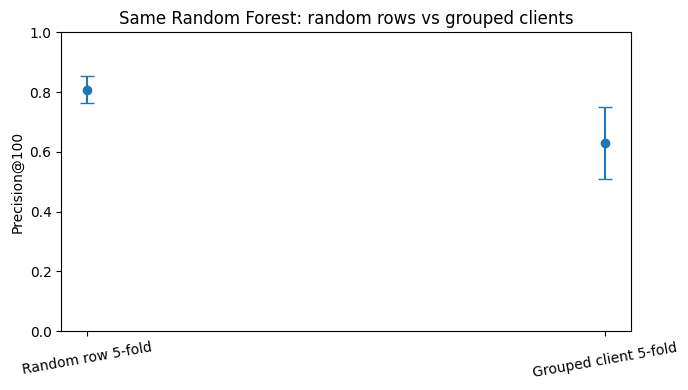

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    split_comparison["validation"],
    split_comparison["mean_p100"],
    yerr=split_comparison["std_p100"],
    fmt="o",
    capsize=5,
)
ax.set_ylabel("Precision@100")
ax.set_title("Same Random Forest: random rows vs grouped clients")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 11. Primary robustness estimate — nested grouped validation

This is the strongest validation in the notebook.

For each outer fold:

1. Hold out an unseen group of clients.
2. Tune hyperparameters **only inside the remaining clients** with inner GroupKFold.
3. Refit on all outer-training clients.
4. Evaluate once on the outer held-out clients.

We do this for Random Forest and Logistic Regression. The baselines are evaluated on exactly the same outer test clients.

This estimate is more important than the single original 7-client result.


In [17]:
OUTER_SPLITS = min(5, model_df["client_id"].nunique())
INNER_SPLITS = 4

X_all = model_df[feature_cols].copy()
y_all = model_df[target_col].copy()
groups_all = model_df["client_id"].copy()

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
outer_rows = []

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer_cv.split(X_all, y_all, groups=groups_all), start=1
):
    outer_train = model_df.iloc[outer_train_idx].copy()
    outer_test = model_df.iloc[outer_test_idx].copy()

    X_outer_train = outer_train[feature_cols].copy()
    y_outer_train = outer_train[target_col].copy()
    g_outer_train = outer_train["client_id"].copy()
    X_outer_test = outer_test[feature_cols].copy()
    y_outer_test = outer_test[target_col].copy()

    assert set(outer_train["client_id"]).isdisjoint(set(outer_test["client_id"]))

    # Inner tuning: Random Forest.
    inner_rf = grouped_parameter_search(
        rf_base,
        rf_grid,
        X_outer_train,
        y_outer_train,
        g_outer_train,
        n_splits=INNER_SPLITS,
    )
    fold_rf_params = dict(inner_rf.iloc[0]["params"])
    fold_rf = clone(rf_base).set_params(**fold_rf_params)
    fold_rf.fit(X_outer_train, y_outer_train)
    rf_scores = fold_rf.predict_proba(X_outer_test)[:, 1]

    # Inner tuning: Logistic Regression.
    inner_log = grouped_parameter_search(
        logistic_base,
        logistic_grid,
        X_outer_train,
        y_outer_train,
        g_outer_train,
        n_splits=INNER_SPLITS,
    )
    fold_log_params = dict(inner_log.iloc[0]["params"])
    fold_log = clone(logistic_base).set_params(**fold_log_params)
    fold_log.fit(X_outer_train, y_outer_train)
    log_scores = fold_log.predict_proba(X_outer_test)[:, 1]

    week4_scores = week4_baseline_scores(outer_train, outer_test)
    momentum_scores = momentum_only_scores(outer_test)

    score_map = {
        "Random Forest": rf_scores,
        "Logistic Regression": log_scores,
        "Momentum-only Baseline": momentum_scores,
        "Week 4 Baseline": week4_scores,
    }

    for name, scores in score_map.items():
        metrics = evaluate_ranking(name, y_outer_test, scores)
        macro = macro_client_precision_at_k(outer_test, scores, k=100)

        outer_rows.append({
            "outer_fold": outer_fold,
            "model": name,
            "train_clients": outer_train["client_id"].nunique(),
            "test_clients": outer_test["client_id"].nunique(),
            "test_rows": len(outer_test),
            "base_rate": metrics["base_rate"],
            "precision_at_100": metrics["precision_at_100"],
            "macro_client_p100": macro["mean"],
            "average_precision": metrics["average_precision"],
            "roc_auc": metrics["roc_auc"],
            "rf_params": fold_rf_params if name == "Random Forest" else None,
            "logistic_params": fold_log_params if name == "Logistic Regression" else None,
        })

    print(
        f"Outer fold {outer_fold}/{OUTER_SPLITS} complete | "
        f"train clients={outer_train['client_id'].nunique()} | "
        f"test clients={outer_test['client_id'].nunique()} | "
        f"RF P@100={precision_at_k(y_outer_test, rf_scores):.1%} | "
        f"Logistic P@100={precision_at_k(y_outer_test, log_scores):.1%}"
    )

outer_results = pd.DataFrame(outer_rows)


Outer fold 1/5 complete | train clients=33 | test clients=1 | RF P@100=84.0% | Logistic P@100=88.0%
Outer fold 2/5 complete | train clients=33 | test clients=1 | RF P@100=79.0% | Logistic P@100=85.0%
Outer fold 3/5 complete | train clients=26 | test clients=8 | RF P@100=63.0% | Logistic P@100=46.0%
Outer fold 4/5 complete | train clients=23 | test clients=11 | RF P@100=68.0% | Logistic P@100=62.0%
Outer fold 5/5 complete | train clients=21 | test clients=13 | RF P@100=74.0% | Logistic P@100=60.0%


In [18]:
nested_summary = (
    outer_results.groupby("model", as_index=False)
    .agg(
        folds=("outer_fold", "nunique"),
        mean_base_rate=("base_rate", "mean"),
        mean_p100=("precision_at_100", "mean"),
        std_p100=("precision_at_100", "std"),
        min_p100=("precision_at_100", "min"),
        max_p100=("precision_at_100", "max"),
        mean_macro_client_p100=("macro_client_p100", "mean"),
        std_macro_client_p100=("macro_client_p100", "std"),
        mean_average_precision=("average_precision", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
    )
    .sort_values("mean_p100", ascending=False)
    .reset_index(drop=True)
)

print("Nested grouped validation summary:")
display(nested_summary.style.format({
    "mean_base_rate": "{:.1%}",
    "mean_p100": "{:.1%}",
    "std_p100": "{:.1%}",
    "min_p100": "{:.1%}",
    "max_p100": "{:.1%}",
    "mean_macro_client_p100": "{:.1%}",
    "std_macro_client_p100": "{:.1%}",
    "mean_average_precision": "{:.3f}",
    "mean_roc_auc": "{:.3f}",
}))

print("\nFold-by-fold Precision@100:")
display(
    outer_results.pivot(
        index="outer_fold", columns="model", values="precision_at_100"
    ).style.format("{:.1%}")
)


Nested grouped validation summary:


,model,folds,mean_base_rate,mean_p100,std_p100,min_p100,max_p100,mean_macro_client_p100,std_macro_client_p100,mean_average_precision,mean_roc_auc
0,Random Forest,5,32.1%,73.6%,8.4%,63.0%,84.0%,55.1%,25.1%,0.491,0.672
1,Momentum-only Baseline,5,32.1%,71.6%,12.6%,59.0%,87.0%,55.6%,27.4%,0.448,0.619
2,Logistic Regression,5,32.1%,68.2%,17.8%,46.0%,88.0%,56.2%,28.5%,0.477,0.659
3,Week 4 Baseline,5,32.1%,34.4%,7.0%,27.0%,45.0%,33.6%,8.3%,0.355,0.542



Fold-by-fold Precision@100:


model,Logistic Regression,Momentum-only Baseline,Random Forest,Week 4 Baseline
outer_fold,,,,
1,88.0%,87.0%,84.0%,33.0%
2,85.0%,83.0%,79.0%,45.0%
3,46.0%,66.0%,63.0%,37.0%
4,62.0%,59.0%,68.0%,27.0%
5,60.0%,63.0%,74.0%,30.0%


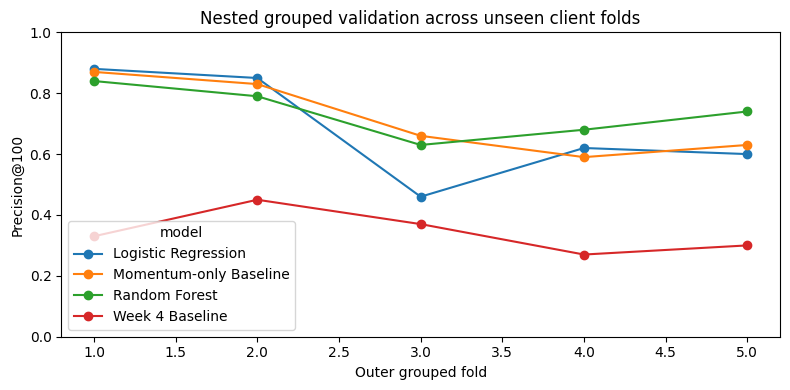

In [19]:
plot_df = outer_results.pivot(
    index="outer_fold", columns="model", values="precision_at_100"
)

ax = plot_df.plot(marker="o", figsize=(8, 4))
ax.set_ylabel("Precision@100")
ax.set_xlabel("Outer grouped fold")
ax.set_title("Nested grouped validation across unseen client folds")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 12. Repeated client-holdout sensitivity check

Nested CV above is the primary estimate. This additional test answers the practical question:

> If I happened to draw a different ~20% set of test clients, how much would the reported Precision@100 move?

To keep runtime reasonable, this section freezes the Random Forest hyperparameters chosen from the original training clients and **re-trains the model from scratch** on every split. Because the frozen hyperparameters were chosen earlier on this same dataset, treat this as a **sensitivity diagnostic**, not a second independent final estimate.


In [20]:
N_REPEATED_SPLITS = 10

repeated_splitter = GroupShuffleSplit(
    n_splits=N_REPEATED_SPLITS,
    test_size=TEST_CLIENT_FRACTION,
    random_state=2026,
)

repeated_rows = []
rf_sensitivity_model = clone(rf_base).set_params(**rf_best_params)

for split_no, (tr_idx, te_idx) in enumerate(
    repeated_splitter.split(X_all, y_all, groups=groups_all), start=1
):
    split_train = model_df.iloc[tr_idx].copy()
    split_test = model_df.iloc[te_idx].copy()

    assert set(split_train["client_id"]).isdisjoint(set(split_test["client_id"]))

    X_tr = split_train[feature_cols]
    y_tr = split_train[target_col]
    X_te = split_test[feature_cols]
    y_te = split_test[target_col]

    model = clone(rf_sensitivity_model)
    model.fit(X_tr, y_tr)
    rf_scores = model.predict_proba(X_te)[:, 1]

    week4_scores = week4_baseline_scores(split_train, split_test)
    momentum_scores = momentum_only_scores(split_test)

    for name, scores in {
        "Random Forest": rf_scores,
        "Momentum-only Baseline": momentum_scores,
        "Week 4 Baseline": week4_scores,
    }.items():
        macro = macro_client_precision_at_k(split_test, scores, k=100)
        repeated_rows.append({
            "split": split_no,
            "model": name,
            "test_clients": split_test["client_id"].nunique(),
            "test_rows": len(split_test),
            "base_rate": float(y_te.mean()),
            "precision_at_100": precision_at_k(y_te, scores, k=100),
            "macro_client_p100": macro["mean"],
        })

    print(
        f"Split {split_no:02d}: "
        f"RF P@100={precision_at_k(y_te, rf_scores):.1%} | "
        f"test clients={split_test['client_id'].nunique()}"
    )

repeated_results = pd.DataFrame(repeated_rows)

repeated_summary = (
    repeated_results.groupby("model", as_index=False)
    .agg(
        splits=("split", "nunique"),
        mean_base_rate=("base_rate", "mean"),
        mean_p100=("precision_at_100", "mean"),
        std_p100=("precision_at_100", "std"),
        min_p100=("precision_at_100", "min"),
        max_p100=("precision_at_100", "max"),
        mean_macro_client_p100=("macro_client_p100", "mean"),
    )
    .sort_values("mean_p100", ascending=False)
)

print("\nRepeated client-holdout sensitivity summary:")
display(repeated_summary.style.format({
    "mean_base_rate": "{:.1%}",
    "mean_p100": "{:.1%}",
    "std_p100": "{:.1%}",
    "min_p100": "{:.1%}",
    "max_p100": "{:.1%}",
    "mean_macro_client_p100": "{:.1%}",
}))


Split 01: RF P@100=81.0% | test clients=7
Split 02: RF P@100=69.0% | test clients=7
Split 03: RF P@100=84.0% | test clients=7
Split 04: RF P@100=83.0% | test clients=7
Split 05: RF P@100=68.0% | test clients=7
Split 06: RF P@100=59.0% | test clients=7
Split 07: RF P@100=69.0% | test clients=7
Split 08: RF P@100=82.0% | test clients=7
Split 09: RF P@100=77.0% | test clients=7
Split 10: RF P@100=54.0% | test clients=7

Repeated client-holdout sensitivity summary:


,model,splits,mean_base_rate,mean_p100,std_p100,min_p100,max_p100,mean_macro_client_p100
1,Random Forest,10,32.7%,72.6%,10.5%,54.0%,84.0%,45.6%
0,Momentum-only Baseline,10,32.7%,70.9%,10.5%,58.0%,87.0%,43.3%
2,Week 4 Baseline,10,32.7%,36.3%,10.0%,21.0%,49.0%,32.6%


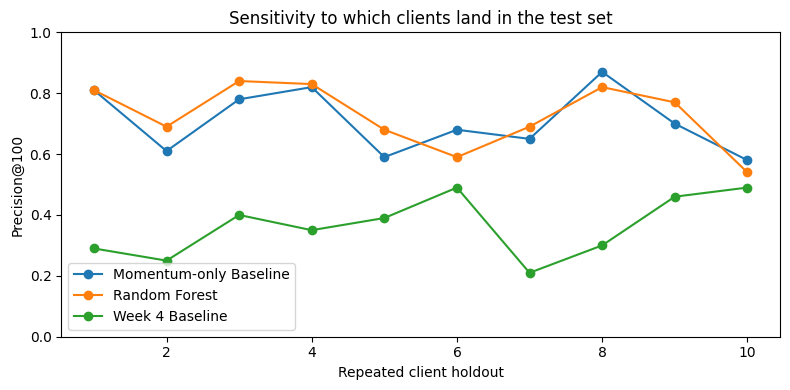

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, group in repeated_results.groupby("model"):
    ax.plot(group["split"], group["precision_at_100"], marker="o", label=name)

ax.set_xlabel("Repeated client holdout")
ax.set_ylabel("Precision@100")
ax.set_title("Sensitivity to which clients land in the test set")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


## 13. Error analysis on the original unseen-client holdout

We inspect the model chosen by grouped CV inside the original training clients. We do **not** expose client names or raw queries.


In [22]:
selected_model_name = cv_selection_table.iloc[0]["model"]
selected_model = best_rf if selected_model_name == "Random Forest" else best_logistic
selected_scores = original_scores[selected_model_name]

error_df = test_df[
    [
        target_col,
        "avg_daily_imp_early",
        "avg_daily_imp_late",
        "imp_momentum_pct",
        "ctr_first_half",
        "ctr_change_pp",
        "avg_position_first_half",
        "position_change",
    ]
].copy()
error_df["risk_score"] = selected_scores

top_false_positives = (
    error_df[error_df[target_col] == 0]
    .sort_values("risk_score", ascending=False)
    .head(5)
)

missed_declines = (
    error_df[error_df[target_col] == 1]
    .sort_values("risk_score", ascending=True)
    .head(5)
)

print("Selected model:", selected_model_name)
print("\nHigh-confidence false positives:")
display(top_false_positives)
print("\nLow-ranked true declines:")
display(missed_declines)


Selected model: Random Forest

High-confidence false positives:


,is_declining_proxy,avg_daily_imp_early,avg_daily_imp_late,imp_momentum_pct,ctr_first_half,ctr_change_pp,avg_position_first_half,position_change,risk_score
29069,0,146.857143,12.750,-91.318093,0.088496,0.980392,1.969912,8.675975,0.913111
27100,0,92.428571,14.250,-84.582689,0.000000,0.000000,1.852825,2.381057,0.904600
9658,0,292.285714,19.250,-93.413978,0.000000,0.000000,3.547727,9.751780,0.893461
10849,0,116.714286,22.625,-80.615055,0.000000,0.000000,6.625251,19.334312,0.887710
9914,0,61.142857,11.375,-81.396028,0.000000,0.000000,5.077071,13.338605,0.883658



Low-ranked true declines:


,is_declining_proxy,avg_daily_imp_early,avg_daily_imp_late,imp_momentum_pct,ctr_first_half,ctr_change_pp,avg_position_first_half,position_change,risk_score
10038,1,3.571429,5.875,64.500000,0.0,0.0,52.305556,13.336170,0.141417
12987,1,3.285714,7.000,113.043478,0.0,0.0,57.556962,4.404503,0.152455
7064,1,4.571429,5.000,9.375000,0.0,0.0,50.111111,13.306250,0.181449
46932,1,4.285714,6.000,40.000000,0.0,0.0,27.307692,9.058333,0.184611
28899,1,3.714286,4.250,14.423077,0.0,0.0,15.733333,14.325792,0.185354


## 14. Feature importance sanity check

Permutation importance is measured on the original held-out clients with Average Precision. A very dominant feature is investigated rather than celebrated.


In [23]:
perm = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)


,feature,importance_mean,importance_std
0,imp_momentum_log,0.074932,0.004552
1,log_imp_first_half,0.035296,0.001661
2,imp_momentum_pct,0.032788,0.002861
3,ctr_first_half,0.018948,0.001224
4,avg_position_first_half,0.013817,0.002381
5,log_clicks_first_half,0.010369,0.000595
6,click_change_per_day,0.001388,0.000309
7,position_change,0.001367,0.000965
8,ctr_change_pp,0.000194,0.000313
9,active_rate_first_half,0.000000,0.000000


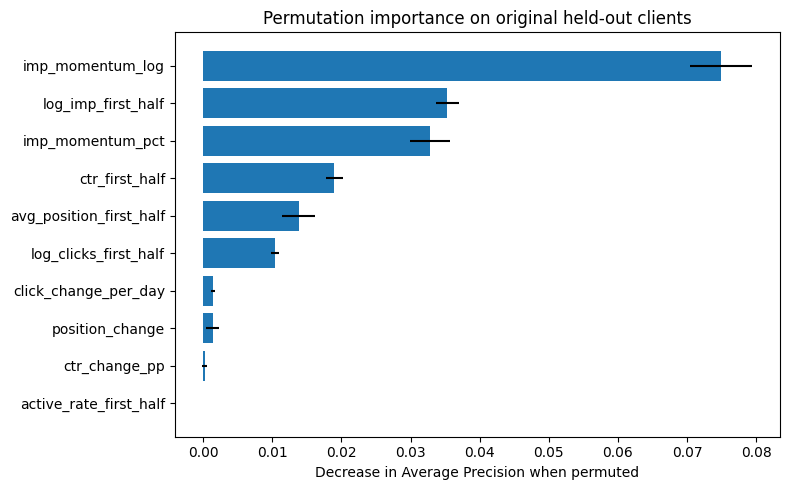

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
top_imp = importance_df.head(10).sort_values("importance_mean")
ax.barh(top_imp["feature"], top_imp["importance_mean"], xerr=top_imp["importance_std"])
ax.set_xlabel("Decrease in Average Precision when permuted")
ax.set_title("Permutation importance on original held-out clients")
plt.tight_layout()
plt.show()


## 15. Decision summary — do not overclaim

The final capstone claim should be based primarily on **nested grouped validation**, with the original 7-client holdout reported as one supporting point estimate.

Interpretation guide:

- If Random Forest clearly beats both baselines across nested folds, the ML ranking adds evidence beyond a simple trend rule.
- If Random Forest and Logistic Regression are close, say that the simpler model is competitive; do not claim complexity is essential.
- If the momentum-only baseline is almost as strong as ML, that is an important finding: most of the value may come from the momentum signal itself.
- If pooled P@100 is high but macro-client P@100 is much lower, performance is uneven across clients.
- A large fold-to-fold standard deviation means the exact score is not stable across client mix.
- These results are **observed decision-support performance on this March cohort**, not a causal claim and not a model of Google's algorithm.


In [25]:
# Compact block to send back for review.
rf_nested = nested_summary[nested_summary["model"] == "Random Forest"].iloc[0]
log_nested = nested_summary[nested_summary["model"] == "Logistic Regression"].iloc[0]
mom_nested = nested_summary[nested_summary["model"] == "Momentum-only Baseline"].iloc[0]
week4_nested = nested_summary[nested_summary["model"] == "Week 4 Baseline"].iloc[0]

rf_repeat = repeated_summary[repeated_summary["model"] == "Random Forest"].iloc[0]

print("=" * 72)
print("SEND THIS SUMMARY BACK FOR REVIEW")
print("=" * 72)
print(f"Modeling rows / clients: {len(model_df):,} / {model_df['client_id'].nunique()}")
print()
print(
    "Momentum ablation — level only vs level+momentum: "
    f"{momentum_ablation.iloc[0]['best_grouped_cv_p100']:.1%} -> "
    f"{momentum_ablation.iloc[1]['best_grouped_cv_p100']:.1%}"
)
print()
print(
    "Corrected random CV:  "
    f"{random_cv_scores.mean():.1%} ± {random_cv_scores.std():.1%}"
)
print(
    "Corrected grouped CV: "
    f"{grouped_cv_scores.mean():.1%} ± {grouped_cv_scores.std():.1%}"
)
print()
print(
    "Nested mean base rate: "
    f"{rf_nested['mean_base_rate']:.1%}"
)
print(
    "Nested RF P@100:      "
    f"{rf_nested['mean_p100']:.1%} ± {rf_nested['std_p100']:.1%} "
    f"(range {rf_nested['min_p100']:.1%}–{rf_nested['max_p100']:.1%})"
)
print(
    "Nested Logistic P@100:"
    f" {log_nested['mean_p100']:.1%} ± {log_nested['std_p100']:.1%}"
)
print(
    "Nested momentum P@100:"
    f" {mom_nested['mean_p100']:.1%} ± {mom_nested['std_p100']:.1%}"
)
print(
    "Nested Week4 P@100:   "
    f"{week4_nested['mean_p100']:.1%} ± {week4_nested['std_p100']:.1%}"
)
print()
print(
    "Nested RF macro-client P@100: "
    f"{rf_nested['mean_macro_client_p100']:.1%}"
)
print(
    "Repeated-holdout RF P@100:    "
    f"{rf_repeat['mean_p100']:.1%} ± {rf_repeat['std_p100']:.1%} "
    f"(range {rf_repeat['min_p100']:.1%}–{rf_repeat['max_p100']:.1%})"
)
print("=" * 72)


SEND THIS SUMMARY BACK FOR REVIEW
Modeling rows / clients: 61,795 / 34

Momentum ablation — level only vs level+momentum: 48.6% -> 60.4%

Corrected random CV:  80.8% ± 4.5%
Corrected grouped CV: 63.0% ± 12.0%

Nested mean base rate: 32.1%
Nested RF P@100:      73.6% ± 8.4% (range 63.0%–84.0%)
Nested Logistic P@100: 68.2% ± 17.8%
Nested momentum P@100: 71.6% ± 12.6%
Nested Week4 P@100:   34.4% ± 7.0%

Nested RF macro-client P@100: 55.1%
Repeated-holdout RF P@100:    72.6% ± 10.5% (range 54.0%–84.0%)


## What to send me after Run all

Please send either the executed notebook or screenshots/copy-paste of these outputs:

1. **Original holdout results table**
2. **Corrected random vs grouped CV table**
3. **Nested grouped validation summary**
4. **Fold-by-fold nested Precision@100 table**
5. **Repeated client-holdout sensitivity summary**
6. The final **SEND THIS SUMMARY BACK FOR REVIEW** block

Then we can decide, based on the evidence, whether the current Random Forest is strong enough for the capstone, whether Logistic Regression is equally defensible, or whether momentum itself explains most of the result. After that we can write the final report with claims that match the evidence.
